# Import Libraries

In [162]:
import warnings
warnings.filterwarnings("ignore")

In [163]:
import scanpy as sc 
import pygenelab as pgl
import decoupler as dc
import pandas as pd
from scipy.stats import rankdata
import matplotlib.pyplot as plt

# Set Constants

In [164]:
C_scANVI = ["Fast IIB"]
sex = ["M"]

# make file id
sex_id = "_".join(sex)
cell_type_id = "_".join(
    ct.replace("Fast ", "").replace(" ", "_").replace("/", "_")
    for ct in C_scANVI
)

file_id = f"{sex_id}_Mice_{cell_type_id}"

file_id

'M_Mice_IIB'

# Get Dataset

In [165]:
# load complete mice dataset
MICE_DATASET_PATH = (
    r"/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/"
    r"integrated_samples/objects/adata_harmony_celloracle_compatible_v2.h5ad"
)
mice_dataset =  sc.read_h5ad(MICE_DATASET_PATH)

In [166]:
# subset Fast IIX and Fast IIB
adata = pgl.subset_adata_by_obs(mice_dataset, filters={"C_scANVI": C_scANVI,
                                                        "sex": sex})
display(adata.obs["C_scANVI"].value_counts())

C_scANVI
Fast IIB    18449
Name: count, dtype: int64

# Get Geneset

In [167]:
# mice all pathways path
MICE_ALL_PATHWAYS = "/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/msigdb.v2024.1.Mm.symbols.gmt"

# specify pathway
pathway = "REACTOME_PYRUVATE_METABOLISM"

# load pathway genes
pathway_genes = pgl.convert_gmt_to_decoupler_format(MICE_ALL_PATHWAYS, include_pathways=[pathway], gene_origin="mice")
display(len(pathway_genes))
display(pathway_genes.head())

45

,source,target
0,REACTOME_PYRUVATE_METABOLISM,Armc8
1,REACTOME_PYRUVATE_METABOLISM,Dlat
2,REACTOME_PYRUVATE_METABOLISM,Dld
3,REACTOME_PYRUVATE_METABOLISM,Fahd1
4,REACTOME_PYRUVATE_METABOLISM,Gid4


In [168]:
# check if genes are in adata
genes_in_adata = pgl.check_genes_in_adata(pathway_genes, adata)
display(genes_in_adata.keys())
display(genes_in_adata["genes_found_in_adata"])

dict_keys(['total_genes_checked', 'genes_found_in_adata', 'genes_missing_from_adata', 'matched_genes', 'missing_genes'])

4

# Calculate Scores

In [169]:
%%time

# get scores
dc.mt.aucell(
    adata,
    pathway_genes,
    raw=False,
    verbose=True,
    tmin = 4 # only 4 common genes are present
)

2026-05-14 09:01:13 | [INFO] aucell - Running aucell
2026-05-14 09:01:13 | [INFO] Extracted omics mat with 18449 rows (observations) and 3000 columns (features)
2026-05-14 09:01:13 | [WARNING] 63 features of mat are empty, they will be removed
2026-05-14 09:01:13 | [WARNING] weight not found in net.columns, adding it as:
net['weight'] = 1
2026-05-14 09:01:13 | [INFO] Network has 4 unique features and 1 unique sources
2026-05-14 09:01:13 | [INFO] aucell - calculating 1 AUCs for 2937 targets across 18449 observations, categorizing features at rank=147
100%|██████████| 18449/18449 [00:03<00:00, 4863.74it/s]
2026-05-14 09:01:17 | [INFO] aucell - done


CPU times: user 4min 1s, sys: 49.5 ms, total: 4min 1s
Wall time: 3.84 s


In [170]:
# store pathway scores into obs
adata.obs[pathway] = adata.obsm["score_aucell"][pathway].copy()
display(adata.obs[pathway].head(10))

AAACCCAAGAACCCGA-1    0.000000
AAACCCAAGCAGCAGT-1    0.000000
AAACCCAAGTCGGGAT-1    0.000000
AAACCCACAAGAGCTG-1    0.157439
AAACCCACAGACGATG-1    0.212803
AAACCCATCAGGAAGC-1    0.000000
AAACGAACAGGACGAT-1    0.076125
AAACGAAGTCACTAGT-1    0.192042
AAACGAATCGACGATT-1    0.067474
AAACGCTAGTCTGTAC-1    0.055363
Name: REACTOME_PYRUVATE_METABOLISM, dtype: float64

In [171]:
# prepare per group score
group_score = pgl.prepare_group_score_df(adata, 
                                            group_col="condition",
                                            value_col=pathway,
                                            dropna=True)
display(group_score.head())

,condition,REACTOME_PYRUVATE_METABOLISM
0,KO,0.000000
1,KO,0.000000
2,KO,0.000000
3,KO,0.157439
4,KO,0.212803


In [172]:
# get a score summary
score_summary = pgl.summarize_score_by_group(group_score,
                                            group_col="condition",
                                            score_col=pathway)
display(score_summary)

,condition,count,mean,median,std,min,max
0,KO,11131,0.055315,0.000000,0.076561,0.0,0.475779
1,WT,7318,0.063469,0.017301,0.081791,0.0,0.522491


# Calculate Cliffs Delta

In [173]:
# calculate cliffs delta
cliffs_delta, _ = pgl.calculate_score_cliffs_delta(adata,
                       pathway,
                       group_col="condition",
                       group1="WT",
                       group2="KO")
display(cliffs_delta)

,score_col,WT_count,KO_count,WT_mean,KO_mean,WT_median,KO_median,WT_std,KO_std,WT_min,KO_min,WT_max,KO_max,mean_difference,median_difference,cliffs_delta,abs_cliffs_delta,higher_group
0,REACTOME_PYRUVATE_METABOLISM,7318,11131,0.063469,0.055315,0.017301,0.0,0.081791,0.076561,0.0,0.0,0.522491,0.475779,0.008154,0.017301,0.056894,0.056894,WT


# Plot

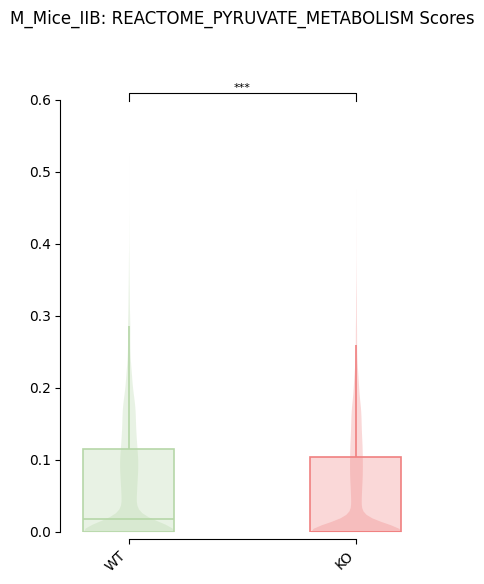

<Figure size 640x480 with 0 Axes>

In [174]:
# choose order
sample_order = ["WT", "KO"]

# palette keys must match age_label values
palette = {
    "WT": "#B6D7A8",
    "KO": "#F08080"
}

# plot violin box plot
fig_violin_box = pgl.plot_violin_box_combo(group_score,
                                           x_var="condition",
                                           y_var=pathway,
                                           title=f"{file_id}: {pathway} Scores",
                                           palette=palette,
                                           x_ticks=sample_order,
                                           show_scatter=False)

display(fig_violin_box)

In [175]:
# subset wt and get gene correlation
adata_wt = pgl.subset_adata_by_obs(adata, filters={"condition": "WT"})
ranked_genes_wt = pgl.compute_gene_correlation_against_score(adata_wt, 
                                                              pgl.get_pathway_genes(pathway_genes, pathway), 
                                                              score=pathway)
display(ranked_genes_wt.head())

# subset ko and get gene correlation
adata_ko = pgl.subset_adata_by_obs(adata, filters={"condition": "KO"})
ranked_genes_ko = pgl.compute_gene_correlation_against_score(adata_ko, 
                                                              pgl.get_pathway_genes(pathway_genes, pathway), 
                                                              score=pathway)
display(ranked_genes_ko.head())

,gene,spearman_corr,rank
0,Me3,0.525873,1
1,Pcx,0.480472,2
2,Pdk4,0.404123,3
3,Ldhb,0.079455,4


,gene,spearman_corr,rank
0,Me3,0.563976,1
1,Pcx,0.551797,2
2,Pdk4,0.290650,3
3,Ldhb,0.092702,4


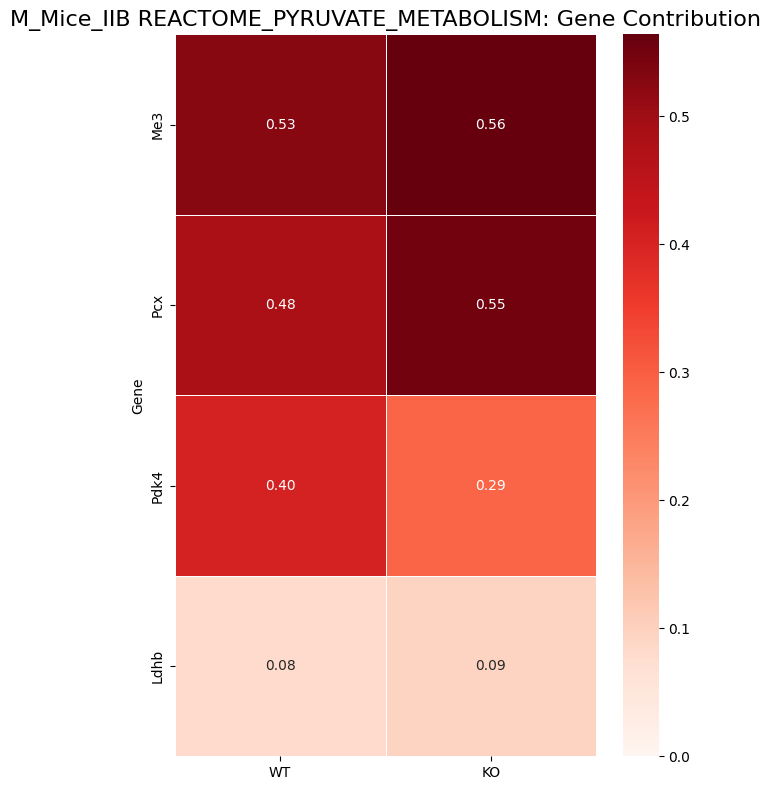

In [176]:
gene_contribution_df, fig_gene_contribution_heatmap, ax_gene_contribution = pgl.plot_gene_contribution_heatmap(
    {"WT": ranked_genes_wt,
     "KO": ranked_genes_ko},
     title=f"{file_id} {pathway}: Gene Contribution"
)

# Save

saved: Output/Pyruvate_Metabolism/M_Mice_IIB_REACTOME_PYRUVATE_METABOLISM_Violin_Box_SVG.svg
saved: Output/Pyruvate_Metabolism/M_Mice_IIB_REACTOME_PYRUVATE_METABOLISM_Violin_Box_PNG.png
saved: Output/Pyruvate_Metabolism/M_Mice_IIB_REACTOME_PYRUVATE_METABOLISM_Gene_Contribution_Heatmap_SVG.svg
saved: Output/Pyruvate_Metabolism/M_Mice_IIB_REACTOME_PYRUVATE_METABOLISM_Gene_Contribution_Heatmap_PNG.png


PosixPath('Output/Pyruvate_Metabolism/Cliffs_Delta_M_Mice_IIB_SVG.svg')

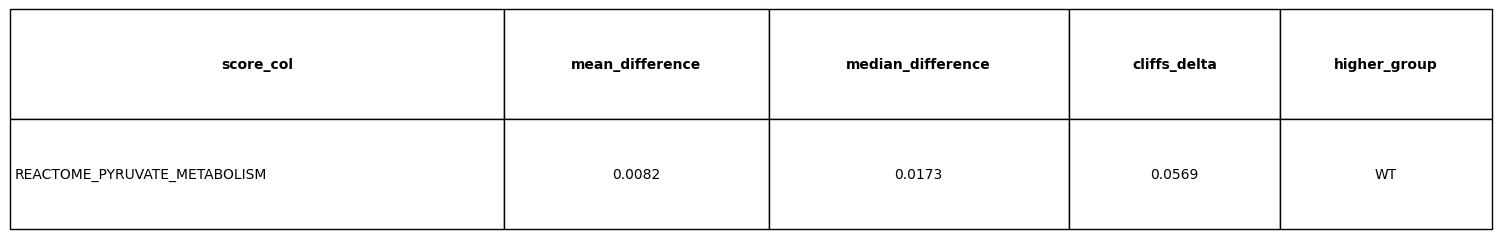

In [177]:
# save image

from pathlib import Path

# figures to save
figures_to_save = {
    "Violin_Box": fig_violin_box,
    "Gene_Contribution_Heatmap": fig_gene_contribution_heatmap
}

# output folder
output_dir = Path("Output/Pyruvate_Metabolism")
output_dir.mkdir(parents=True, exist_ok=True)


# save each figure as svg and png
for plot_type, fig in figures_to_save.items():

    # create output paths
    svg_path = output_dir / f"{file_id}_{pathway}_{plot_type}_SVG.svg"
    png_path = output_dir / f"{file_id}_{pathway}_{plot_type}_PNG.png"

    # save editable svg
    pgl.save_editable_svg(
        fig=fig,
        output_path=svg_path
    )

    # save png
    pgl.save_fig_as_png(
        fig=fig,
        output_path=png_path
    )

    print(f"saved: {svg_path}")
    print(f"saved: {png_path}")

plot_df = cliffs_delta[["score_col", "mean_difference", "median_difference", "cliffs_delta", "higher_group"]]
fig_cliffs_delta = pgl.save_df_table_image(plot_df)
pgl.save_fig_as_png(fig_cliffs_delta, f"Output/Pyruvate_Metabolism/Cliffs_Delta_{file_id}_PNG.png")
pgl.save_editable_svg(fig_cliffs_delta, f"Output/Pyruvate_Metabolism/Cliffs_Delta_{file_id}_SVG.svg")